# Modelagem de Churn - Regressão Logística
## PRT Seguros

Modelo baseline linear com balanceamento de classe para previsão de churn de clientes.

## 1. IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, accuracy_score
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint as sp_randint, uniform as sp_uniform

# Paleta PRT
PRT_NAVY = "#19284F"
PRT_GREEN = "#39694B"
PRT_GRAY = "#737C8A"
RANDOM_STATE = 42

## 2. CARREGAR E PREPARAR DADOS

In [2]:
df = pd.read_csv("../bases/tabelas_unificadas/Base_Unificada_Outer.csv")
print(f"Shape inicial: {df.shape}")
df.head()

Shape inicial: (100000, 84)


,cod_individuo,num_apolices_ativas,valor_premio_anual,tempo_cliente_dias,data_primeira_apolice,num_produtos_contratados,valor_cobertura_total,franquia_media,pagamento_em_dia,desconto_aplicado_pct,...,regiao_NaN,regiao_Nordeste,regiao_Oeste,regiao_Regiao Oeste,regiao_Sudeste,regiao_Sul,churned,num_apolices_premium,num_apolices_basica,num_apolices_padrao
0,221300000040,2.0,1077.82,2165.0,27/06/2020,2.0,161891.00,1083.49,1.0,0.049,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,0.0,2.0
1,221300000051,1.0,1342.00,4309.0,14/08/2014,4.0,131680.75,753.93,1.0,0.054,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,0.0,1.0
2,221300000085,3.0,1542.00,1550.0,04/03/2022,1.0,81434.11,1732.02,1.0,0.081,...,0.0,0.0,0.0,0.0,1.0,0.0,0,0.0,3.0,0.0
3,221300000119,2.0,1189.46,1651.0,23/11/2021,NaN,121370.92,657.88,1.0,0.033,...,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,2.0
4,221300000218,NaN,620.10,1902.0,17/03/2021,2.0,153965.39,662.30,1.0,0.035,...,0.0,0.0,1.0,0.0,0.0,0.0,0,NaN,NaN,NaN


## 3. REMOVER COLUNAS DE LEAKAGE E DATA

In [3]:
# Remover vazamento
colunas_vazamento = ["score_propensao_churn", "cluster_sugerido_crm"]
presentes = [c for c in colunas_vazamento if c in df.columns]
if presentes:
    print(f"Removendo colunas de vazamento: {presentes}")
    df = df.drop(columns=presentes)

# Remover colunas de data (causam explosão de features)
colunas_data = ["data_primeira_apolice", "data_nascimento"]
presentes_data = [c for c in colunas_data if c in df.columns]
if presentes_data:
    print(f"Removendo colunas de data: {presentes_data}")
    df = df.drop(columns=presentes_data)

# Remover multicolinearidade
if "renovacoes_consecutivas" in df.columns:
    print(f"Correlação time_cliente_dias vs renovacoes_consecutivas: {df[['tempo_cliente_dias', 'renovacoes_consecutivas']].corr().iloc[0, 1]:.3f}")
    df = df.drop(columns=["renovacoes_consecutivas"])

print(f"Shape após limpeza: {df.shape}")

Removendo colunas de vazamento: ['score_propensao_churn', 'cluster_sugerido_crm']
Removendo colunas de data: ['data_primeira_apolice', 'data_nascimento']
Correlação time_cliente_dias vs renovacoes_consecutivas: 0.942
Shape após limpeza: (100000, 79)


## 4. DEFINIR TARGET E FEATURES

In [4]:
TARGET = "churned"
y = df[TARGET]
X = df.drop(columns=[TARGET])

cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categóricas: {len(cat_cols)} | Numéricas: {len(num_cols)}")

Categóricas: 0 | Numéricas: 78


## 5. ENCODING E TRATAMENTO DE NULOS

In [5]:
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
print(f"Shape após encoding: {X_encoded.shape}")

imputer = SimpleImputer(strategy="median")
X_model = X_encoded.copy()
X_model[:] = imputer.fit_transform(X_model)

assert X_model.isnull().sum().sum() == 0, "Ainda há valores nulos"
print("✓ Sem valores nulos")

Shape após encoding: (100000, 78)
✓ Sem valores nulos


## 6. TRAIN/TEST SPLIT

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras ({y_train.mean():.1%} churn)")
print(f"Teste:  {X_test.shape[0]} amostras ({y_test.mean():.1%} churn)")

Treino: 80000 amostras (12.1% churn)
Teste:  20000 amostras (12.1% churn)


## 7. PADRONIZAÇÃO (Necessária para Regressão Logística)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("✓ Dados padronizados")

✓ Dados padronizados


## 8. TREINAR REGRESSÃO LOGÍSTICA

In [8]:
log_reg = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=RANDOM_STATE
)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print("="*50)
print("REGRESSÃO LOGÍSTICA - RESULTADOS")
print("="*50)
print(classification_report(y_test, y_pred, target_names=["Não-churn", "Churn"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")

REGRESSÃO LOGÍSTICA - RESULTADOS
              precision    recall  f1-score   support

   Não-churn       0.96      0.68      0.79     17581
       Churn       0.25      0.79      0.38      2419

    accuracy                           0.69     20000
   macro avg       0.60      0.73      0.59     20000
weighted avg       0.87      0.69      0.74     20000

ROC-AUC: 0.8022


## 8b. Tuning de Hiperparâmetros (GridSearch / RandomizedSearch)
Aqui executamos GridSearch para Regressão Logística e RandomizedSearch para Random Forest. Otimizamos por ROC-AUC (boa para classes desbalanceadas).

In [ ]:
# GridSearch para Regressão Logística usando Pipeline (padronização + modelo)
pipe = Pipeline([('scaler', StandardScaler()), ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
param_grid = {
    'clf__penalty': ['l1', 'l2'],
    'clf__C': [0.01, 0.1, 1, 10, 100],
    'clf__solver': ['liblinear', 'saga'],
    'clf__class_weight': [None, 'balanced']
}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='roc_auc', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)
print('Logistic GridSearch - best params:', grid.best_params_)
print('Logistic GridSearch - best CV ROC-AUC:', f'{grid.best_score_:.4f}')
# Avaliar no conjunto de teste
y_pred_log = grid.predict(X_test)
y_proba_log = grid.predict_proba(X_test)[:, 1]
print('Acurácia (Logistic - test):', f'{accuracy_score(y_test, y_pred_log)*100:.2f}%')
print(classification_report(y_test, y_pred_log, target_names=['Não-churn', 'Churn']))
print('ROC-AUC (Logistic - test):', f'{roc_auc_score(y_test, y_proba_log):.4f}')

# RandomizedSearch para RandomForest (busca eficiente em espaços grandes)
rf = RandomForestClassifier(random_state=RANDOM_STATE)
param_dist = {
    'n_estimators': sp_randint(50, 500),
    'max_depth': sp_randint(3, 30),
    'min_samples_split': sp_randint(2, 20),
    'min_samples_leaf': sp_randint(1, 10),
    'max_features': ['sqrt', 'log2', 0.2, 0.5],
    'class_weight': [None, 'balanced']
}
rand = RandomizedSearchCV(rf, param_dist, n_iter=40, cv=5, scoring='roc_auc', n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
rand.fit(X_train, y_train)
print('RandomForest RandomizedSearch - best params:', rand.best_params_)
print('RandomForest RandomizedSearch - best CV ROC-AUC:', f'{rand.best_score_:.4f}')
# Avaliar no conjunto de teste
y_pred_rf = rand.predict(X_test)
y_proba_rf = rand.predict_proba(X_test)[:, 1]
print('Acurácia (RF - test):', f'{accuracy_score(y_test, y_pred_rf)*100:.2f}%')
print(classification_report(y_test, y_pred_rf, target_names=['Não-churn', 'Churn']))
print('ROC-AUC (RF - test):', f'{roc_auc_score(y_test, y_proba_rf):.4f}')

# Cross-validation do melhor estimador para verificar estabilidade
scores = cross_val_score(grid.best_estimator_, X_train, y_train, cv=5, scoring='roc_auc')
print('Logistic CV ROC-AUC mean/std:', f'{scores.mean():.4f}', f'{scores.std():.4f}')
scores_rf = cross_val_score(rand.best_estimator_, X_train, y_train, cv=5, scoring='roc_auc')
print('RF CV ROC-AUC mean/std:', f'{scores_rf.mean():.4f}', f'{scores_rf.std():.4f}')

# Salvar melhores modelos em variáveis para uso posterior
best_logistic = grid.best_estimator_
best_rf = rand.best_estimator_

## 8c. Ajuste Manual de Hiperparâmetros
Aqui você pode variar parâmetros importantes um por vez para aprender como cada escolha impacta o score do modelo.

In [ ]:
# Ajuste manual para LogisticRegression: variando C
manual_results = []
C_values = [0.001, 0.01, 0.1, 1, 10]
for C in C_values:
    pipe.set_params(clf__C=C)
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    acc = pipe.fit(X_train, y_train).score(X_test, y_test)
    manual_results.append({'C': C, 'cv_roc_auc': scores.mean(), 'cv_std': scores.std(), 'test_acc': acc})

manual_df = pd.DataFrame(manual_results)
print('LogisticRegression - ajuste manual de C')
print(manual_df.to_string(index=False, float_format='%.4f'))

In [ ]:
# Ajuste manual para RandomForest: alguns parâmetros-chave
rf_manual = RandomForestClassifier(random_state=RANDOM_STATE)
manual_rf = [
    {'n_estimators': 100, 'max_depth': None, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 10, 'min_samples_leaf': 1},
    {'n_estimators': 200, 'max_depth': 20, 'min_samples_leaf': 3},
]
for params in manual_rf:
    rf_manual.set_params(**params)
    scores = cross_val_score(rf_manual, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1)
    rf_manual.fit(X_train, y_train)
    acc = accuracy_score(y_test, rf_manual.predict(X_test))
    print('RF params:', params)
    print('  CV ROC-AUC: %.4f ± %.4f' % (scores.mean(), scores.std()))
    print('  Test accuracy: %.2f%%\n' % (acc * 100))

In [ ]:
# Ajuste de threshold no modelo Logistic otimizado
proba = best_logistic.predict_proba(X_test)[:, 1]
for thresh in [0.3, 0.4, 0.5, 0.6, 0.7]:
    pred = (proba >= thresh).astype(int)
    print(f'Threshold {thresh}: acc = {accuracy_score(y_test, pred)*100:.2f}%')

## 9. MATRIZ DE CONFUSÃO

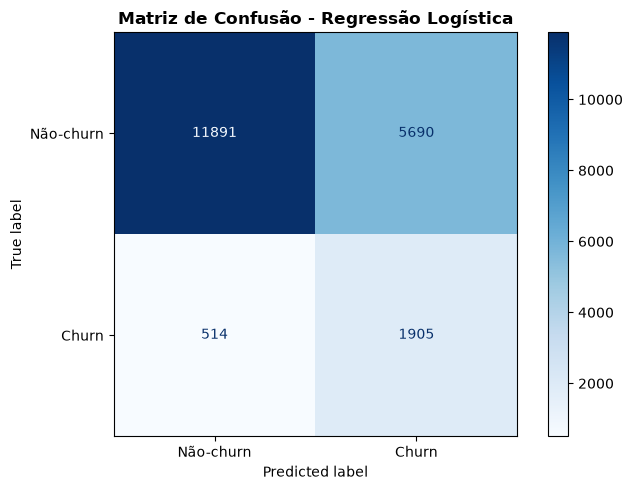

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Não-churn", "Churn"]).plot(
    ax=ax, cmap="Blues", colorbar=True
)
ax.set_title("Matriz de Confusão - Regressão Logística", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

## 10. CURVA ROC

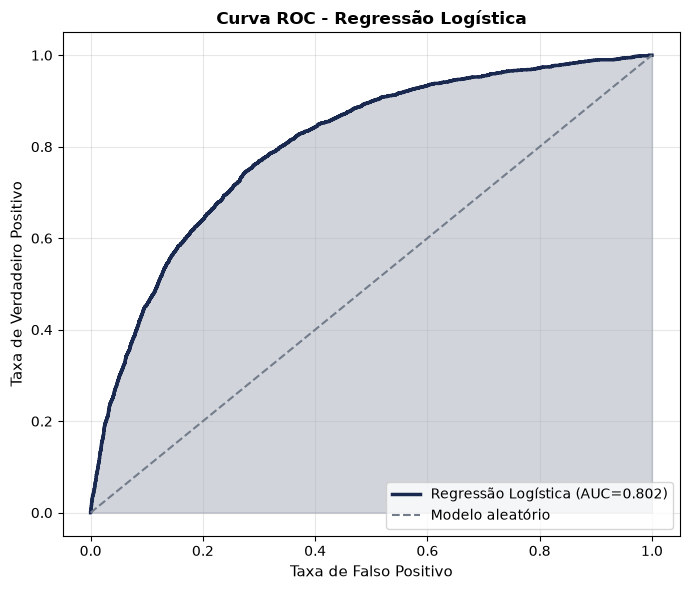

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f"Regressão Logística (AUC={auc:.3f})",
        color=PRT_NAVY, linewidth=2.5)
ax.plot([0, 1], [0, 1], linestyle="--", color=PRT_GRAY, label="Modelo aleatório")
ax.fill_between(fpr, tpr, alpha=0.2, color=PRT_NAVY)

ax.set_xlabel("Taxa de Falso Positivo", fontsize=11)
ax.set_ylabel("Taxa de Verdadeiro Positivo", fontsize=11)
ax.set_title("Curva ROC - Regressão Logística", fontsize=12, fontweight="bold")
ax.legend(loc="lower right", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 11. CURVA PRECISION-RECALL

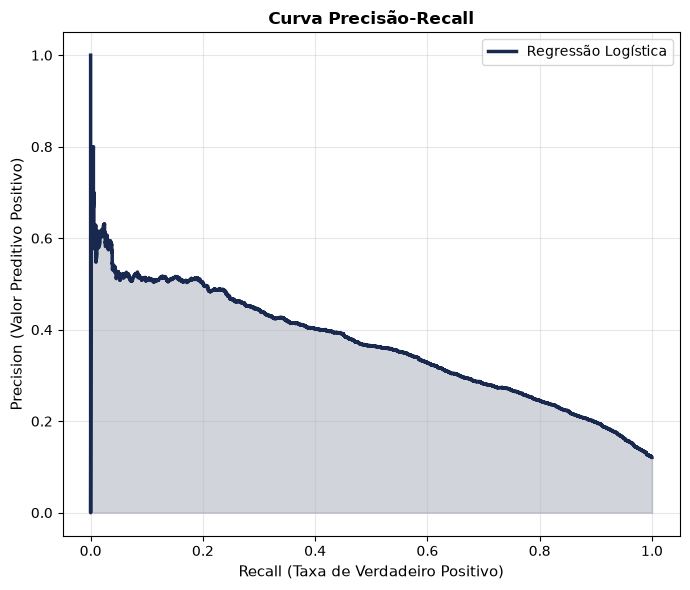

In [11]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall, precision, label="Regressão Logística",
        color=PRT_NAVY, linewidth=2.5)
ax.fill_between(recall, precision, alpha=0.2, color=PRT_NAVY)

ax.set_xlabel("Recall (Taxa de Verdadeiro Positivo)", fontsize=11)
ax.set_ylabel("Precision (Valor Preditivo Positivo)", fontsize=11)
ax.set_title("Curva Precisão-Recall", fontsize=12, fontweight="bold")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. COEFICIENTES DO MODELO (Interpretabilidade)

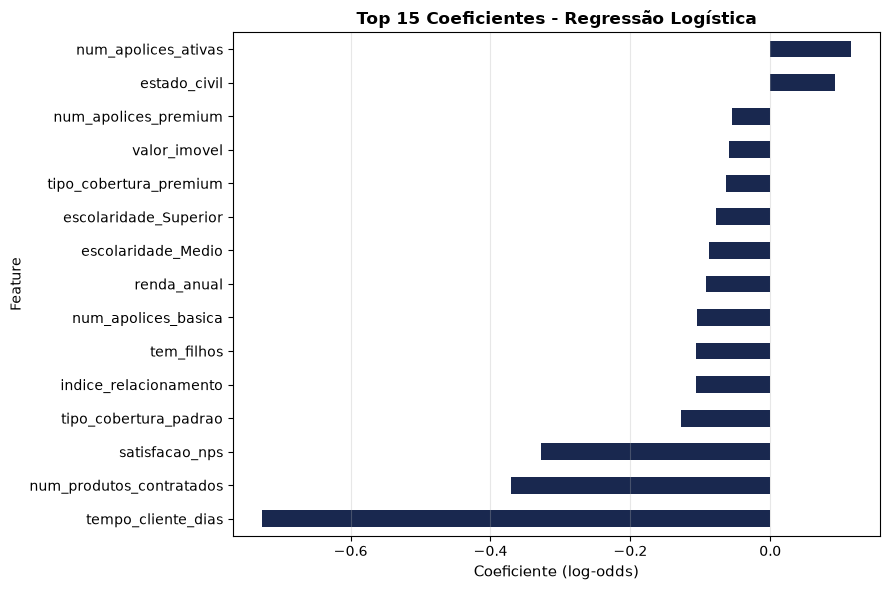


=== COEFICIENTES (Impacto na Probabilidade de Churn) ===
                 Feature  Coeficiente
      tempo_cliente_dias    -0.726275
num_produtos_contratados    -0.370524
          satisfacao_nps    -0.327105
   tipo_cobertura_padrao    -0.127299
     num_apolices_ativas     0.114874
   indice_relacionamento    -0.106265
              tem_filhos    -0.105599
     num_apolices_basica    -0.105283
            estado_civil     0.092627
             renda_anual    -0.092437
      escolaridade_Medio    -0.087415
   escolaridade_Superior    -0.076978
  tipo_cobertura_premium    -0.062583
            valor_imovel    -0.059484
    num_apolices_premium    -0.055309


In [12]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coeficiente': log_reg.coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
coef_df.set_index('Feature')['Coeficiente'].sort_values().plot(
    kind='barh', ax=ax, color=PRT_NAVY
)
ax.set_title("Top 15 Coeficientes - Regressão Logística", fontsize=12, fontweight="bold")
ax.set_xlabel("Coeficiente (log-odds)", fontsize=11)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\n=== COEFICIENTES (Impacto na Probabilidade de Churn) ===")
print(coef_df.to_string(index=False))